## Masking and Patching

We visualize how to create prediction and context masks with `IJEPAMasker`.

In [1]:
import jax
from jax import numpy as jnp
import einops
import matplotlib.pyplot as plt

from jepax.data import build_torch_dataloader
dataloader, _, _, _ = build_torch_dataloader("CIFAR10", data_dir="~/data")
x, y = next(iter(dataloader))

/Users/anton/source/jepax/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


## Helpers

Define helper functions to convert images to patch features by reshaping. Allows us to simulate applying a mask to a sequence of tokens.

In [8]:
PATCH_SIZE = 2
IMG_H, IMG_W = 32, 32
N_PATCH = IMG_H // PATCH_SIZE  # =16 here
M = 4 

def patchify(x, patch_size):
    return einops.rearrange(
        x,
        "(h ph) (w pw) c -> (h w) (c ph pw)",
        ph=patch_size,
        pw=patch_size,
    )

def unpatchify(x, patch_size, n_patch):
    return einops.rearrange(
        x,
        "(h w) (c ph pw) -> (h ph) (w pw) c",
        h=n_patch,
        ph=patch_size,
        pw=patch_size,
    )


def visualize_mask(x, mask, patch_size, n_patch):
    x_masked = jax.vmap(lambda x, m: x * m)(patchify(x, patch_size), mask)
    return unpatchify(x_masked, patch_size, n_patch)


def set_token_mask(tokens, mask, mask_vec):
    return jnp.where(mask[..., None], tokens, mask_vec)

## Sample masks

Sample boolean prediction and context masks, where `True` represents keeping a patch in the encoder
- `mask_ctx` is a `(n_patch**2,)` boolean array
- `mask_pred` is a  `(M, n_patch**2)` boolean array, where `M` is the number of predictor masks

In [9]:
from jepax.model.masker import IJEPAMasker

masker = IJEPAMasker(
    IMG_H, IMG_W, PATCH_SIZE,
    ctx_scale=0.9,
    pred_scale=(0.1, 0.2),
    pred_aspect=(0.75, 1.2),
)
mask_ctx, mask_pred = masker(jax.random.PRNGKey(1), M, flatten=True)

## Visualize

Visualize the sampled masks

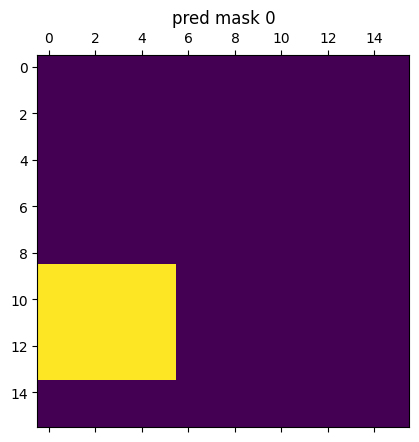

In [11]:
# Single prediction mask
plt.matshow(mask_pred[1].reshape(N_PATCH, N_PATCH))
plt.title("pred mask 0")
plt.show()

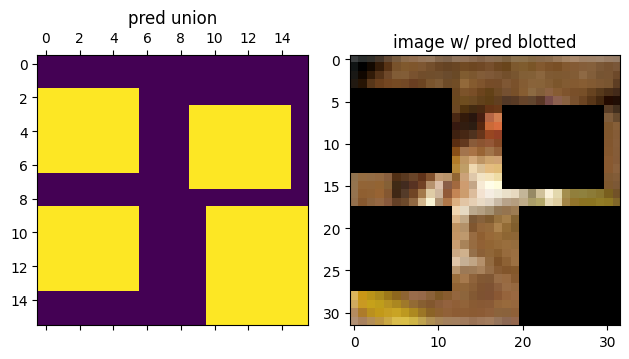

In [12]:
# Union of all prediction masks
mask_pred_union = jnp.any(mask_pred, axis=0)

fig, ax = plt.subplots(1, 2)
ax[0].matshow(mask_pred_union.reshape(N_PATCH, N_PATCH))
ax[0].set_title("pred union")
ax[1].imshow(visualize_mask(x[0], ~mask_pred_union, PATCH_SIZE, N_PATCH))
ax[1].set_title("image w/ pred blotted")
plt.tight_layout()
plt.show()

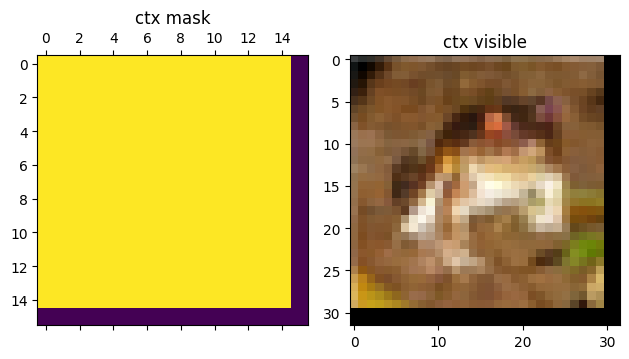

In [13]:
# Context mask
fig, ax = plt.subplots(1, 2)
ax[0].matshow(mask_ctx.reshape(N_PATCH, N_PATCH))
ax[0].set_title("ctx mask")
ax[1].imshow(visualize_mask(x[0], mask_ctx, PATCH_SIZE, N_PATCH))
ax[1].set_title("ctx visible")
plt.tight_layout()
plt.show()

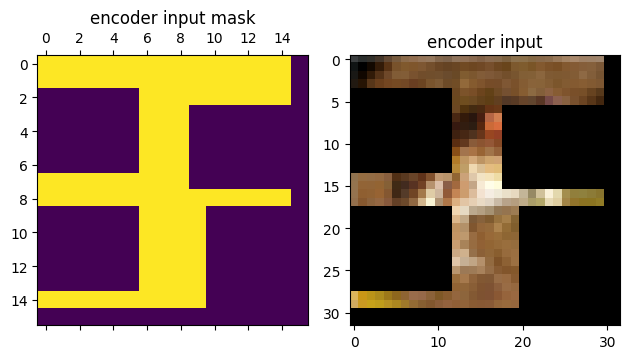

In [14]:
# what the encoder actually sees
mask_total = ~(~mask_ctx | mask_pred_union)

fig, ax = plt.subplots(1, 2)
ax[0].matshow(mask_total.reshape(N_PATCH, N_PATCH))
ax[0].set_title("encoder input mask")
ax[1].imshow(visualize_mask(x[0], mask_total, PATCH_SIZE, N_PATCH))
ax[1].set_title("encoder input")
plt.tight_layout()
plt.show()